In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import fastai
from fastai.vision.all import *
from fastai.metrics import error_rate
from IPython.display import Image
from pathlib import Path

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
'''for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))'''

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


"for dirname, _, filenames in os.walk('/kaggle/input'):\n    for filename in filenames:\n        print(os.path.join(dirname, filename))"

Let's check our fastai version.

In [2]:
fastai.__version__

'2.7.13'

Let's first load in our csv datasets.

In [3]:
train_dir = "/kaggle/input/bttai-nybg-2024/BTTAIxNYBG-train/BTTAIxNYBG-train/"
test_dir =  "/kaggle/input/bttai-nybg-2024/BTTAIxNYBG-test/BTTAIxNYBG-test/"
validation_dir = "/kaggle/input/bttai-nybg-2024/BTTAIxNYBG-validation/BTTAIxNYBG-validation/"

train_path = Path(train_dir)
test_path = Path(test_dir)
validation_path = Path(validation_dir)

train_files = get_image_files(train_path)
test_files = get_image_files(test_path)
validation_files = get_image_files(validation_path)

In [4]:
print("First train file: " + str(train_files[0]))
print("First test file: " + str(test_files[0]))
print("First validation file: " + str(validation_files[0]))

First train file: /kaggle/input/bttai-nybg-2024/BTTAIxNYBG-train/BTTAIxNYBG-train/e8b43636b421a395.jpg
First test file: /kaggle/input/bttai-nybg-2024/BTTAIxNYBG-test/BTTAIxNYBG-test/f0f27252c9e7654c.jpg
First validation file: /kaggle/input/bttai-nybg-2024/BTTAIxNYBG-validation/BTTAIxNYBG-validation/d8da5ada82e9f1b3.jpg


<Axes: >

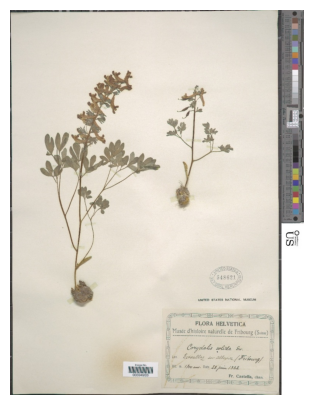

In [5]:
im = PILImage.create(train_files[0])
im.show()

<Axes: >

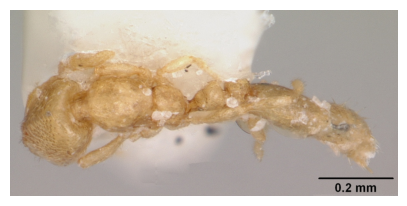

In [6]:
im = PILImage.create(test_files[0])
im.show()

<Axes: >

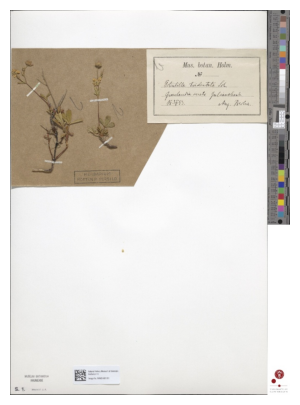

In [7]:
im = PILImage.create(validation_files[0])
im.show()

In [8]:
directory = "../input/bttai-nybg-2024"
csv_filenames = ["BTTAIxNYBG-test.csv", "BTTAIxNYBG-train.csv", "BTTAIxNYBG-validation.csv"]
dfs = [pd.read_csv(os.path.join(directory, fn), header=0) for fn in csv_filenames]
df_test, df_train, df_validation = dfs

In [9]:
df_train.head()

,uniqueID,classLabel,classID,source,imageFile
0,2,occluded-specimens,8,L,a1a8b48e8cb142b3.jpg
1,3,microscope-slides,6,L,79599db2ac9092b6.jpg
2,4,illustrations-color,2,BHL,c449696f2f0d0d92.jpg
3,5,illustrations-color,2,P,80a8f4a393b4e08c.jpg
4,6,animal-specimens,0,AK,041a1c6e73313638.jpg


In [10]:
df_test.head()

,uniqueID,imageFile
0,1,facd4dcd8e869617.jpg
1,9,78c96bb2b2b62579.jpg
2,10,d292d2c4e0e6ad9d.jpg
3,14,3633494929870713.jpg
4,16,dc94b496c8e2d6c4.jpg


In [11]:
df_validation.head()

,uniqueID,classLabel,classID,source,imageFile
0,7,microscope-slides,6,K,f09a8abe9e9e9ef2.jpg
1,20,illustrations-color,2,BHL,a6c6868387c6af8c.jpg
2,37,ordinary-pressed-specimens,9,YU,6062c68e8c34b292.jpg
3,59,animal-specimens,0,CAS,363617271597dfd9.jpg
4,60,biocultural-specimens,1,Met,4218d8d2f42b05e4.jpg


In [12]:
df_all = pd.concat([df_train, df_validation])
df_all.head()

,uniqueID,classLabel,classID,source,imageFile
0,2,occluded-specimens,8,L,a1a8b48e8cb142b3.jpg
1,3,microscope-slides,6,L,79599db2ac9092b6.jpg
2,4,illustrations-color,2,BHL,c449696f2f0d0d92.jpg
3,5,illustrations-color,2,P,80a8f4a393b4e08c.jpg
4,6,animal-specimens,0,AK,041a1c6e73313638.jpg


# EDA

First, let's take a look at some general statistics in our dataset.

In [13]:
print("df_train shape:", df_train.shape)
print("df_validation shape:", df_validation.shape)
print("df_test shape:", df_test.shape)

df_train shape: (81946, 5)
df_validation shape: (10244, 5)
df_test shape: (30690, 2)


In [14]:
df_all.describe(include='all')

,uniqueID,classLabel,classID,source,imageFile
count,92190.000000,92190,92190.000000,92190,92190
unique,NaN,10,NaN,37,92190
top,NaN,ordinary-pressed-specimens,NaN,BHL,a1a8b48e8cb142b3.jpg
freq,NaN,9224,NaN,14277,1
mean,61402.942054,NaN,4.500076,NaN,NaN
std,35487.381667,NaN,2.872395,NaN,NaN
min,2.000000,NaN,0.000000,NaN,NaN
25%,30642.250000,NaN,2.000000,NaN,NaN
50%,61300.500000,NaN,4.000000,NaN,NaN
75%,92199.750000,NaN,7.000000,NaN,NaN


In [15]:
df_all.dtypes

uniqueID       int64
classLabel    object
classID        int64
source        object
imageFile     object
dtype: object

In [16]:
df_all.isnull().sum()

uniqueID      0
classLabel    0
classID       0
source        0
imageFile     0
dtype: int64

In [17]:
duplicate_values_df_all = df_all['imageFile'].duplicated().any()
print("Check if any duplicates in training and validation images: " + str(duplicate_values_df_all))

Check if any duplicates in training and validation images: False


It appears that each unique classLabel corresponds to a classID. Let's investigate this relationship.

In [18]:
class_mapping = df_all.groupby('classID')['classLabel'].unique().str[0].reset_index()
class_mapping

,classID,classLabel
0,0,animal-specimens
1,1,biocultural-specimens
2,2,illustrations-color
3,3,illustrations-gray
4,4,live-plants
5,5,micrographs-transmission-light
6,6,microscope-slides
7,7,mixed-pressed-specimens
8,8,occluded-specimens
9,9,ordinary-pressed-specimens


Text(0.5, 1.0, 'Distribution of Image Classes')

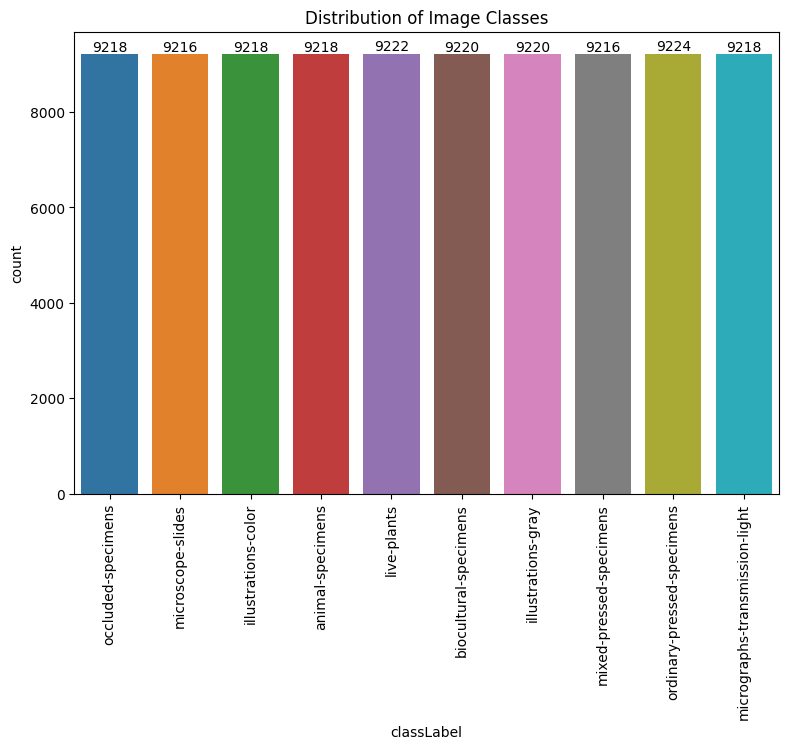

In [19]:
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
ax1 = sns.countplot(data=df_all, x='classLabel')
for container in ax1.containers:
    ax1.bar_label(container)
    ax1.tick_params(axis='x', labelrotation=90)
plt.title('Distribution of Image Classes')

It appears that the classes are all very balanced.

# Modeling

First, let us define the functions we will use in building the model.

In [20]:
# Function for get_items parameter
def get_my_files(x):
    return get_image_files(train_path) + get_image_files(validation_path) 

# Custom Splitter - splits training and validation images
def FileSplitter():
    def _func(pth_in):
        in_valid = False
        if "BTTAIxNYBG-validation/BTTAIxNYBG-validation" in str(pth_in):
            in_valid = True
        return in_valid
    def _inner(o, **kwargs): return FuncSplitter(_func)(o)
    return _inner

# Function to return corresponding class label given image path
def label_func(path):
    path = str(path)
    fname = path.split('/')[-1]
    if "BTTAIxNYBG-train/BTTAIxNYBG-train" in path:
         return df_train[df_train['imageFile'] == fname].iloc[0]['classLabel']
    elif "BTTAIxNYBG-validation/BTTAIxNYBG-validation" in path:
        return df_validation[df_validation['imageFile'] == fname].iloc[0]['classLabel']

Since our input files are separated in train, validation, and test directories but are not separated into sub-directories of each class label, fastai's ImageDataLoaders do not work. Therefore, we will instead use the data block API to build a DataBlock from scratch.    

The get_my_files function we defined above takes in the paths to the training and validation directories. The FileSplitter function returns in_valid for any files in the validation directory path, effectively separating the training and validation files. The label_func function returns the class label of an image as defined in either df_train or df_validation.    

With item_tfms, all images are cropped to a given size. We choose a relatively large image size such as 460, so that either the full width or height of the image is captured, which ensures that we aren’t losing useful information from the data. The batch_tfms takes a set of images and does pre-defined transformations to them, such as rotations, flipping, and changes in brightness. We are applying these transformations to at least 75% of the image pixels in a batch, and then resizing them to a standard image size we define (224), which ideally should be a smaller dimension than what we first used in the item_tfms.

In [21]:
datablock = DataBlock(blocks=(ImageBlock, CategoryBlock),
                   get_items=get_my_files,
                   splitter=FileSplitter(),
                   get_y=label_func,
                   item_tfms=Resize(460),
                   batch_tfms=aug_transforms(size=224, min_scale=0.75))

We now convert our DataBlock datablock to a DataLoaders object, dls. This process may take approximately 20 to 30 minutes.

In [22]:
dls = datablock.dataloaders("/kaggle/input/bttai-nybg-2024/")

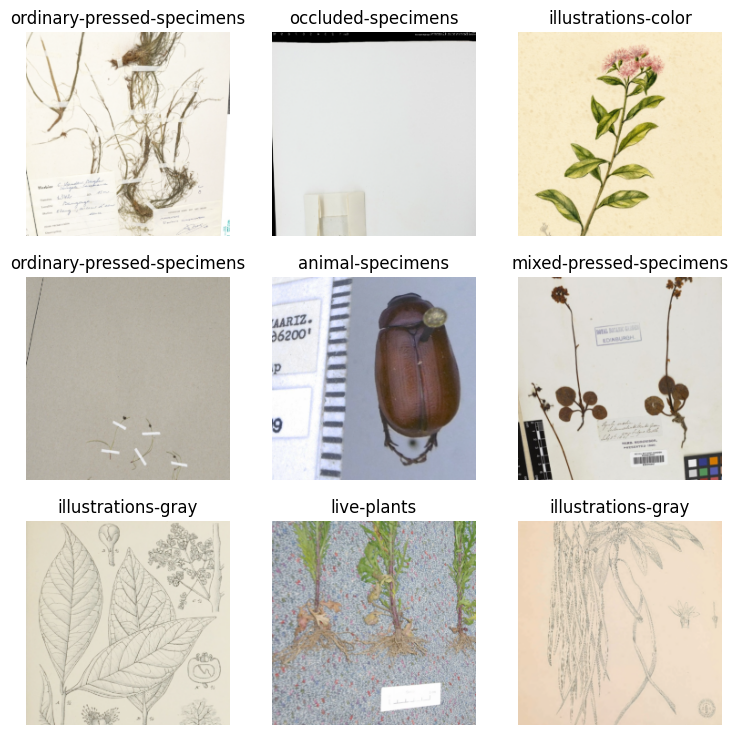

In [23]:
dls.show_batch()

Then we can create a Learner, a fastai object that combines the data and a model for training. This line downloaded a model called ResNet34, pretrained on ImageNet, and adapted it to our specific problem.

In [24]:
learn = vision_learner(dls, resnet50, metrics=accuracy)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 267MB/s]


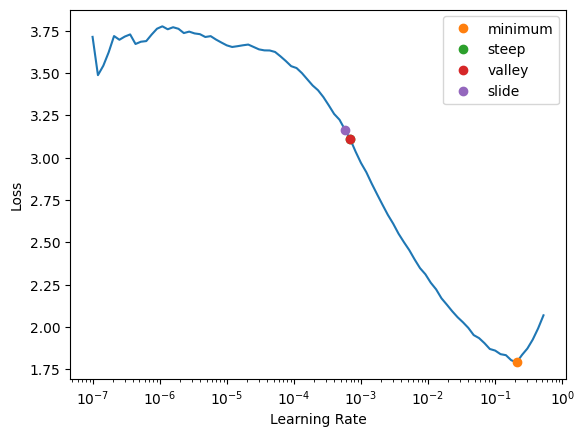

In [25]:
lrs = learn.lr_find(suggest_funcs=(minimum, steep, valley, slide))

In [26]:
learn.fine_tune(10)

epoch,train_loss,valid_loss,accuracy,time
0,0.252006,0.167260,0.937817,22:41


epoch,train_loss,valid_loss,accuracy,time
0,0.127767,0.086301,0.967786,22:35
1,0.115629,0.072264,0.973253,22:29
2,0.096622,0.071895,0.974815,22:32
3,0.093399,0.067843,0.976669,22:37
4,0.073683,0.062505,0.977743,22:27
5,0.064678,0.049885,0.983014,22:33
6,0.048521,0.053757,0.981843,22:27
7,0.035270,0.053213,0.983405,22:38
8,0.029124,0.054979,0.983795,22:35
9,0.030692,0.053206,0.984186,22:34


In [27]:
learn.summary()

Sequential (Input shape: 64 x 3 x 224 x 224)
Layer (type)         Output Shape         Param #    Trainable 
                     64 x 64 x 112 x 112 
Conv2d                                    9408       True      
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     64 x 64 x 56 x 56   
MaxPool2d                                                      
Conv2d                                    4096       True      
BatchNorm2d                               128        True      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
____________________________________________________________________________
                     64 x 256 x 56 x 56  
Conv2d                                    16384      True      
BatchNorm2d                        

In [28]:
interp = ClassificationInterpretation.from_learner(learn)

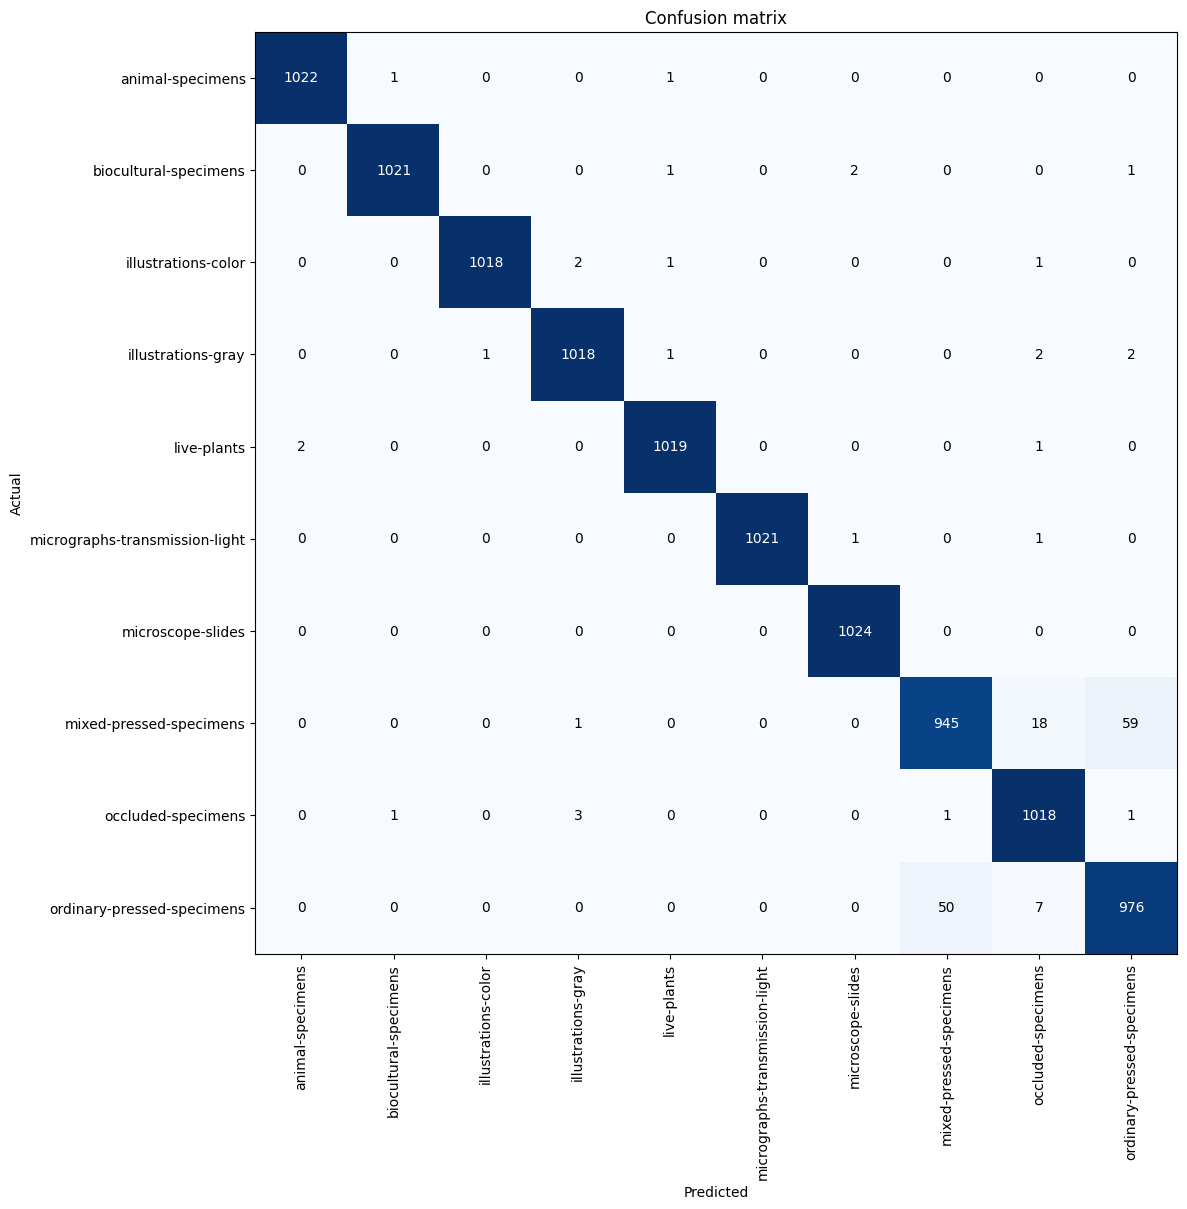

In [29]:
cm = interp.plot_confusion_matrix(figsize=(12, 12))

Let us print out each class label.

In [30]:
for vocab in dls[0].dataset.vocab:
    print(vocab)

animal-specimens
biocultural-specimens
illustrations-color
illustrations-gray
live-plants
micrographs-transmission-light
microscope-slides
mixed-pressed-specimens
occluded-specimens
ordinary-pressed-specimens


We will now define the function test_pred, which calls the predict function for each test image. The function returns a list of the predicted class labels, in the order corresponding to df_test, to match the submission file structure.

In [31]:
def test_pred(test_fnames, pred_list):
    for fname in test_fnames:
        pred = learn.predict(Path(test_dir + fname))
        pred_list.append(pred[0]) # Append just the predicted classLabel
    return pred_list

The function we defined is called for each image in df_test, in order. %%capture is used to prevent the Kaggle notebook hanging, due to fastai's predict function's console outputs.

In [32]:
%%capture
test_fnames = df_test["imageFile"].values
pred_list = []
preds = test_pred(test_fnames, pred_list)

Let us make sure that the class labels are now stored in the preds list.

In [33]:
preds[0:5]

['biocultural-specimens',
 'mixed-pressed-specimens',
 'live-plants',
 'biocultural-specimens',
 'microscope-slides']

We will now make a submission dataframe, adding the classLabel column from our preds list.

In [34]:
submission = pd.DataFrame()
submission["uniqueID"] = df_test["uniqueID"]
submission["classLabel"] = preds
submission.head()

,uniqueID,classLabel
0,1,biocultural-specimens
1,9,mixed-pressed-specimens
2,10,live-plants
3,14,biocultural-specimens
4,16,microscope-slides


Since the submission file requires the classID column instead of a classLabel column, we will map each classLabel to its classID, as defined previously in the class_mapping dataframe. The submission dataframe will then be in the correct format.

In [35]:
label_to_ID_mapping = class_mapping.set_index('classLabel')['classID'].to_dict()
submission['classID'] = submission['classLabel'].map(label_to_ID_mapping)
del submission['classLabel']
submission.head()

,uniqueID,classID
0,1,1
1,9,7
2,10,4
3,14,1
4,16,6


The submission dataframe will now be converted to a csv file.

In [36]:
submission.to_csv('submission.csv', index=False)